# 1. Imports and Data Loading

Imports the libraries used in this notebook and loads the raw dataset from its GitHub raw URL (kept as the source of truth for this project's setup).


In [25]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_profiling import ProfileReport

In [26]:
df = pd.read_csv("https://raw.githubusercontent.com/selomrani/CardProfiler/refs/heads/main/data/raw/dataset-6ab989b678d90892980305.csv")

# 2. Dataset Overview

First look at the data structure: a row preview (`head`), summary statistics (`describe`) and the dataset dimensions (`shape`).


In [27]:
df.head()

,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,C10001,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084
1,C10002,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597
2,C10003,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742
3,C10004,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000
4,C10005,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763


In [28]:
df.describe()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


In [29]:
df.shape

(8950, 8)

# 3. Missing Values and Duplicates

FS1 requires identifying missing values and duplicate rows (brief line 33). A sorted table of missing values (count + %) is added below, as required by brief line 42.


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.isna().sum()

CUST_ID                   0
BALANCE                   0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
CREDIT_LIMIT              1
PAYMENTS                  0
dtype: int64

In [32]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(df) * 100).round(3),
})
missing_summary


,missing_count,missing_pct
CREDIT_LIMIT,1,0.011


# 4. Profiling Report

Automated profile of the whole dataset generated with `data_profiling.ProfileReport` and exported to an HTML report.


In [33]:
report = ProfileReport(df)
report.to_file("../../reports/profling-report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 150.58it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 5. Distribution of Numerical Variables

Histograms with KDE curves for the 7 behavioral variables, with the **skewness coefficient shown in each title** so asymmetric variables are visible at a glance (brief line 39).


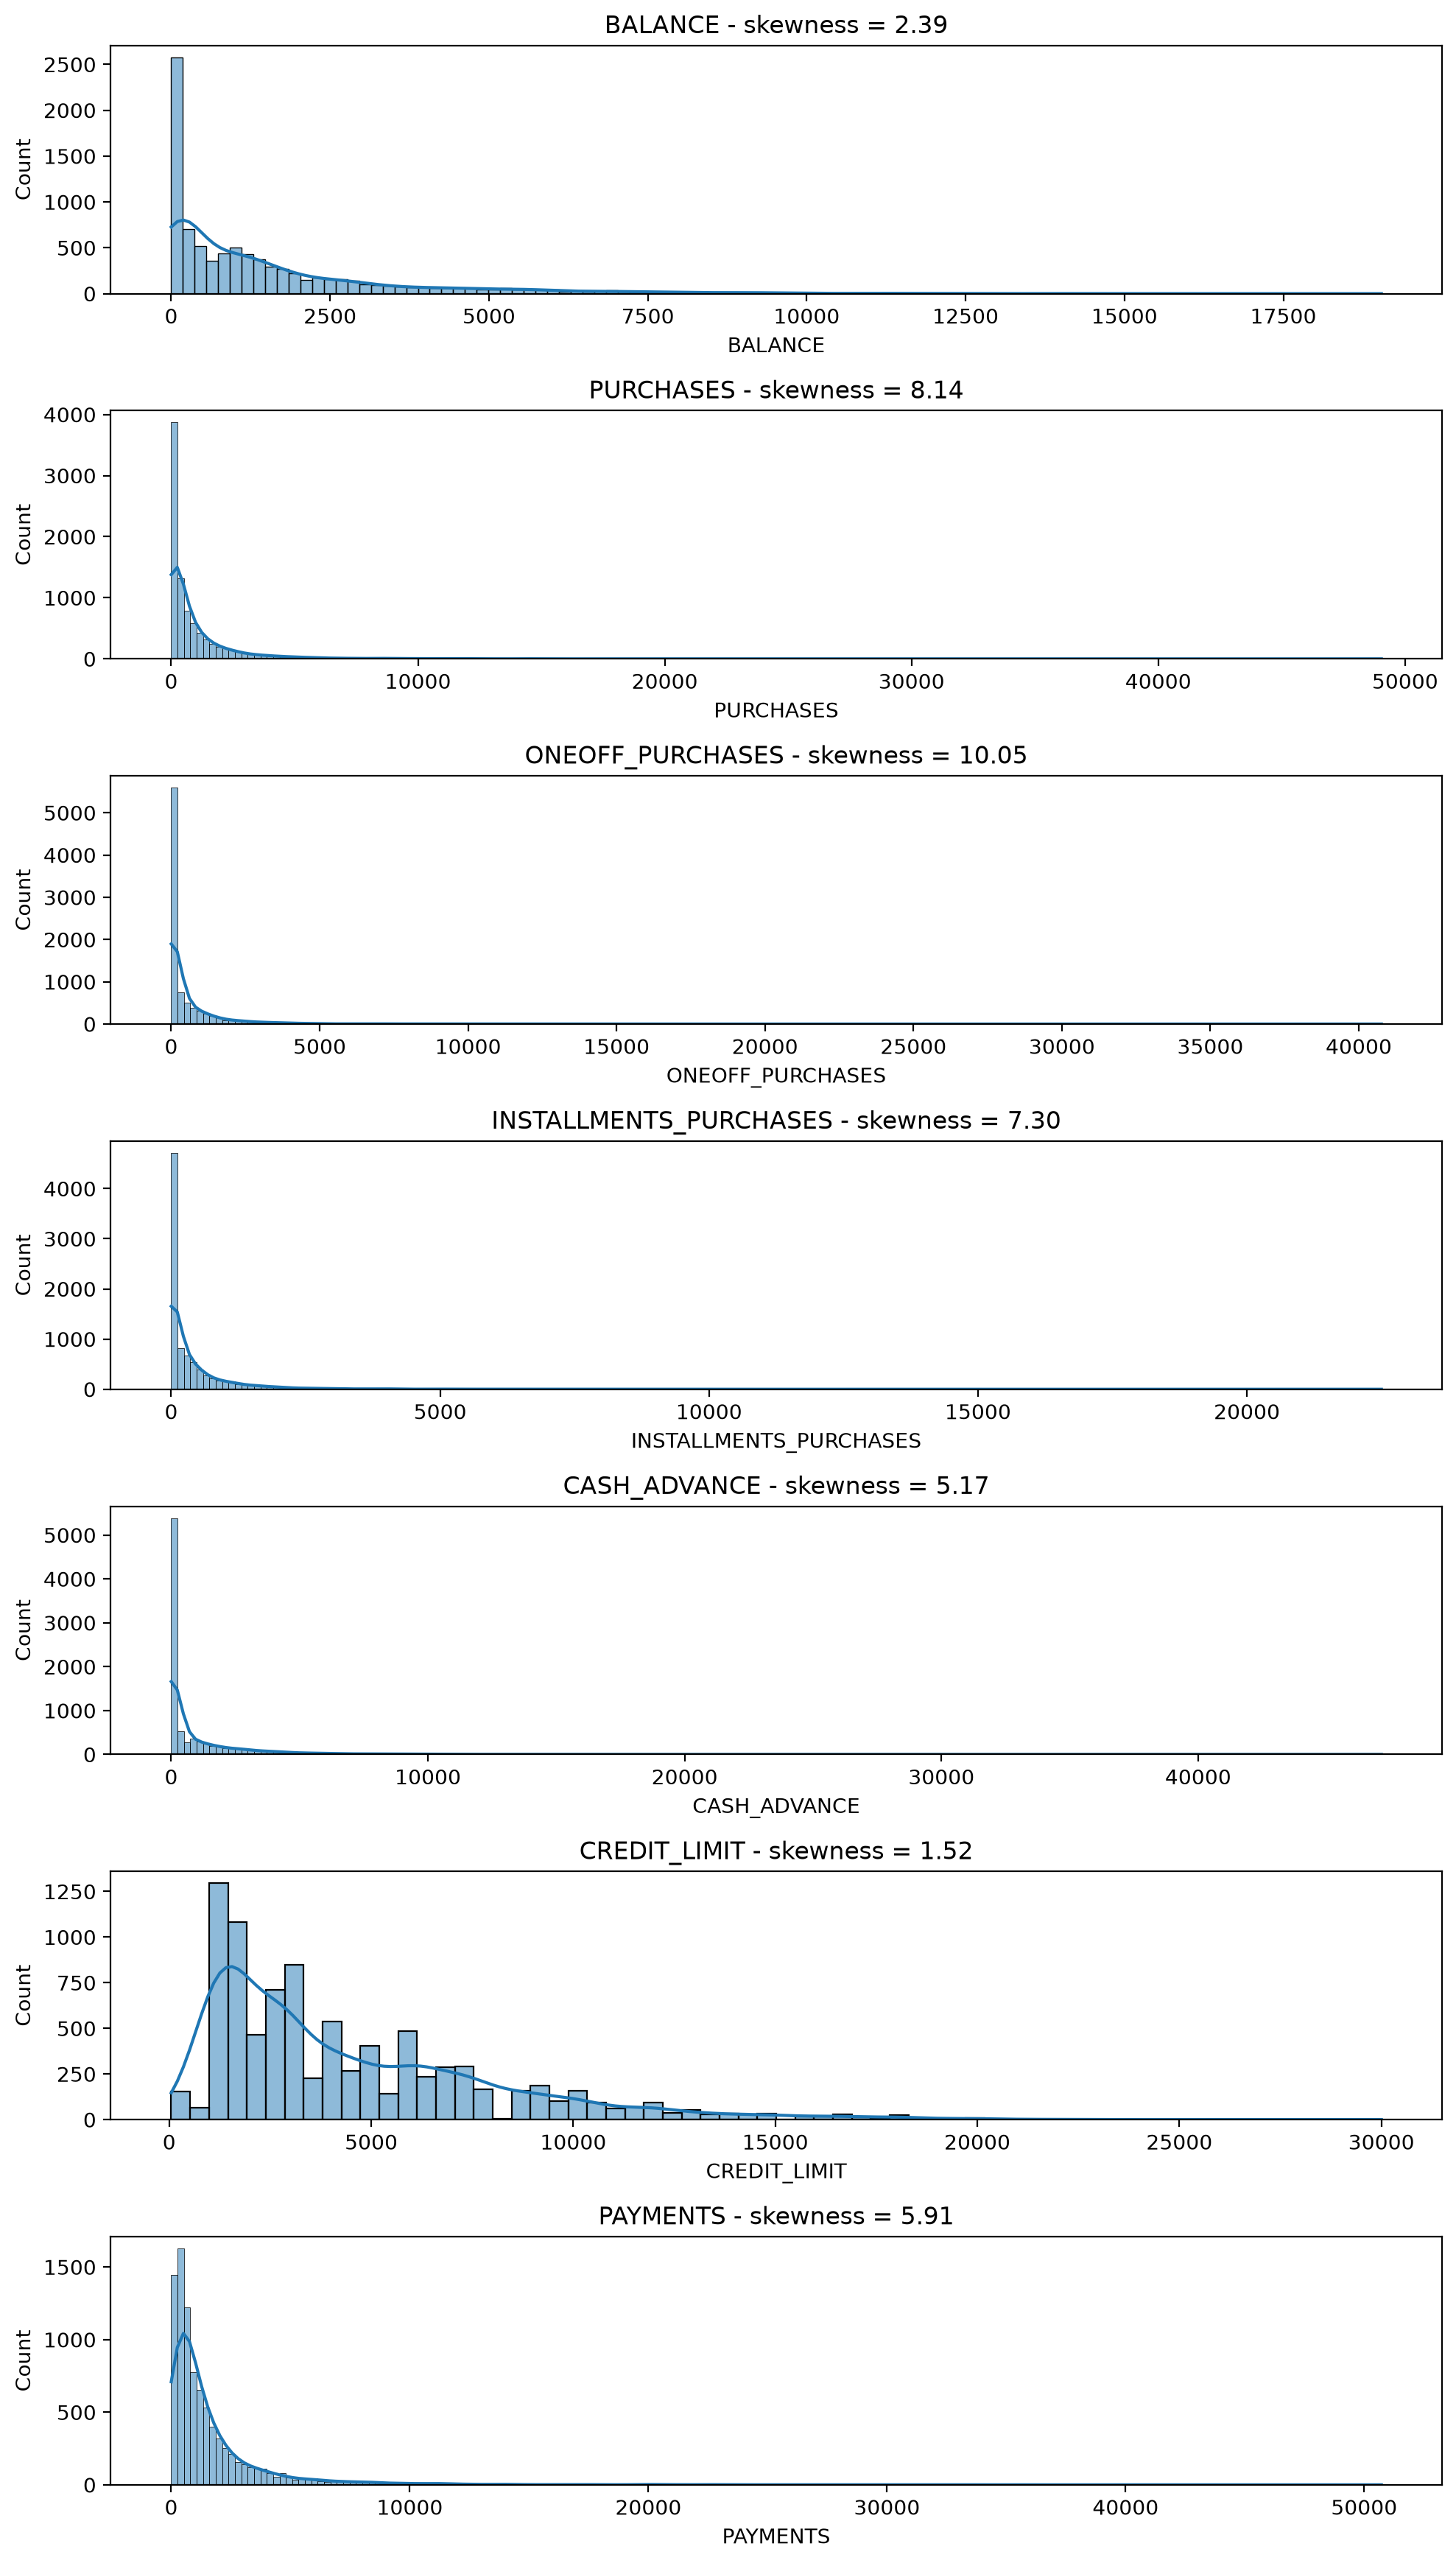

In [34]:
behavioral = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES",
              "INSTALLMENTS_PURCHASES", "CASH_ADVANCE",
              "CREDIT_LIMIT", "PAYMENTS"]

n = len(behavioral)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 2.5 * n))
for ax, col in zip(axes, behavioral):
    skew = df[col].skew()
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"{col} - skewness = {skew:.2f}")
fig.tight_layout()
plt.show()


# 6. Correlation Matrix

Heatmap of the correlation matrix to visualize the relationships between variables (brief line 40). Expected highlight: `PURCHASES` vs `ONEOFF_PURCHASES`.


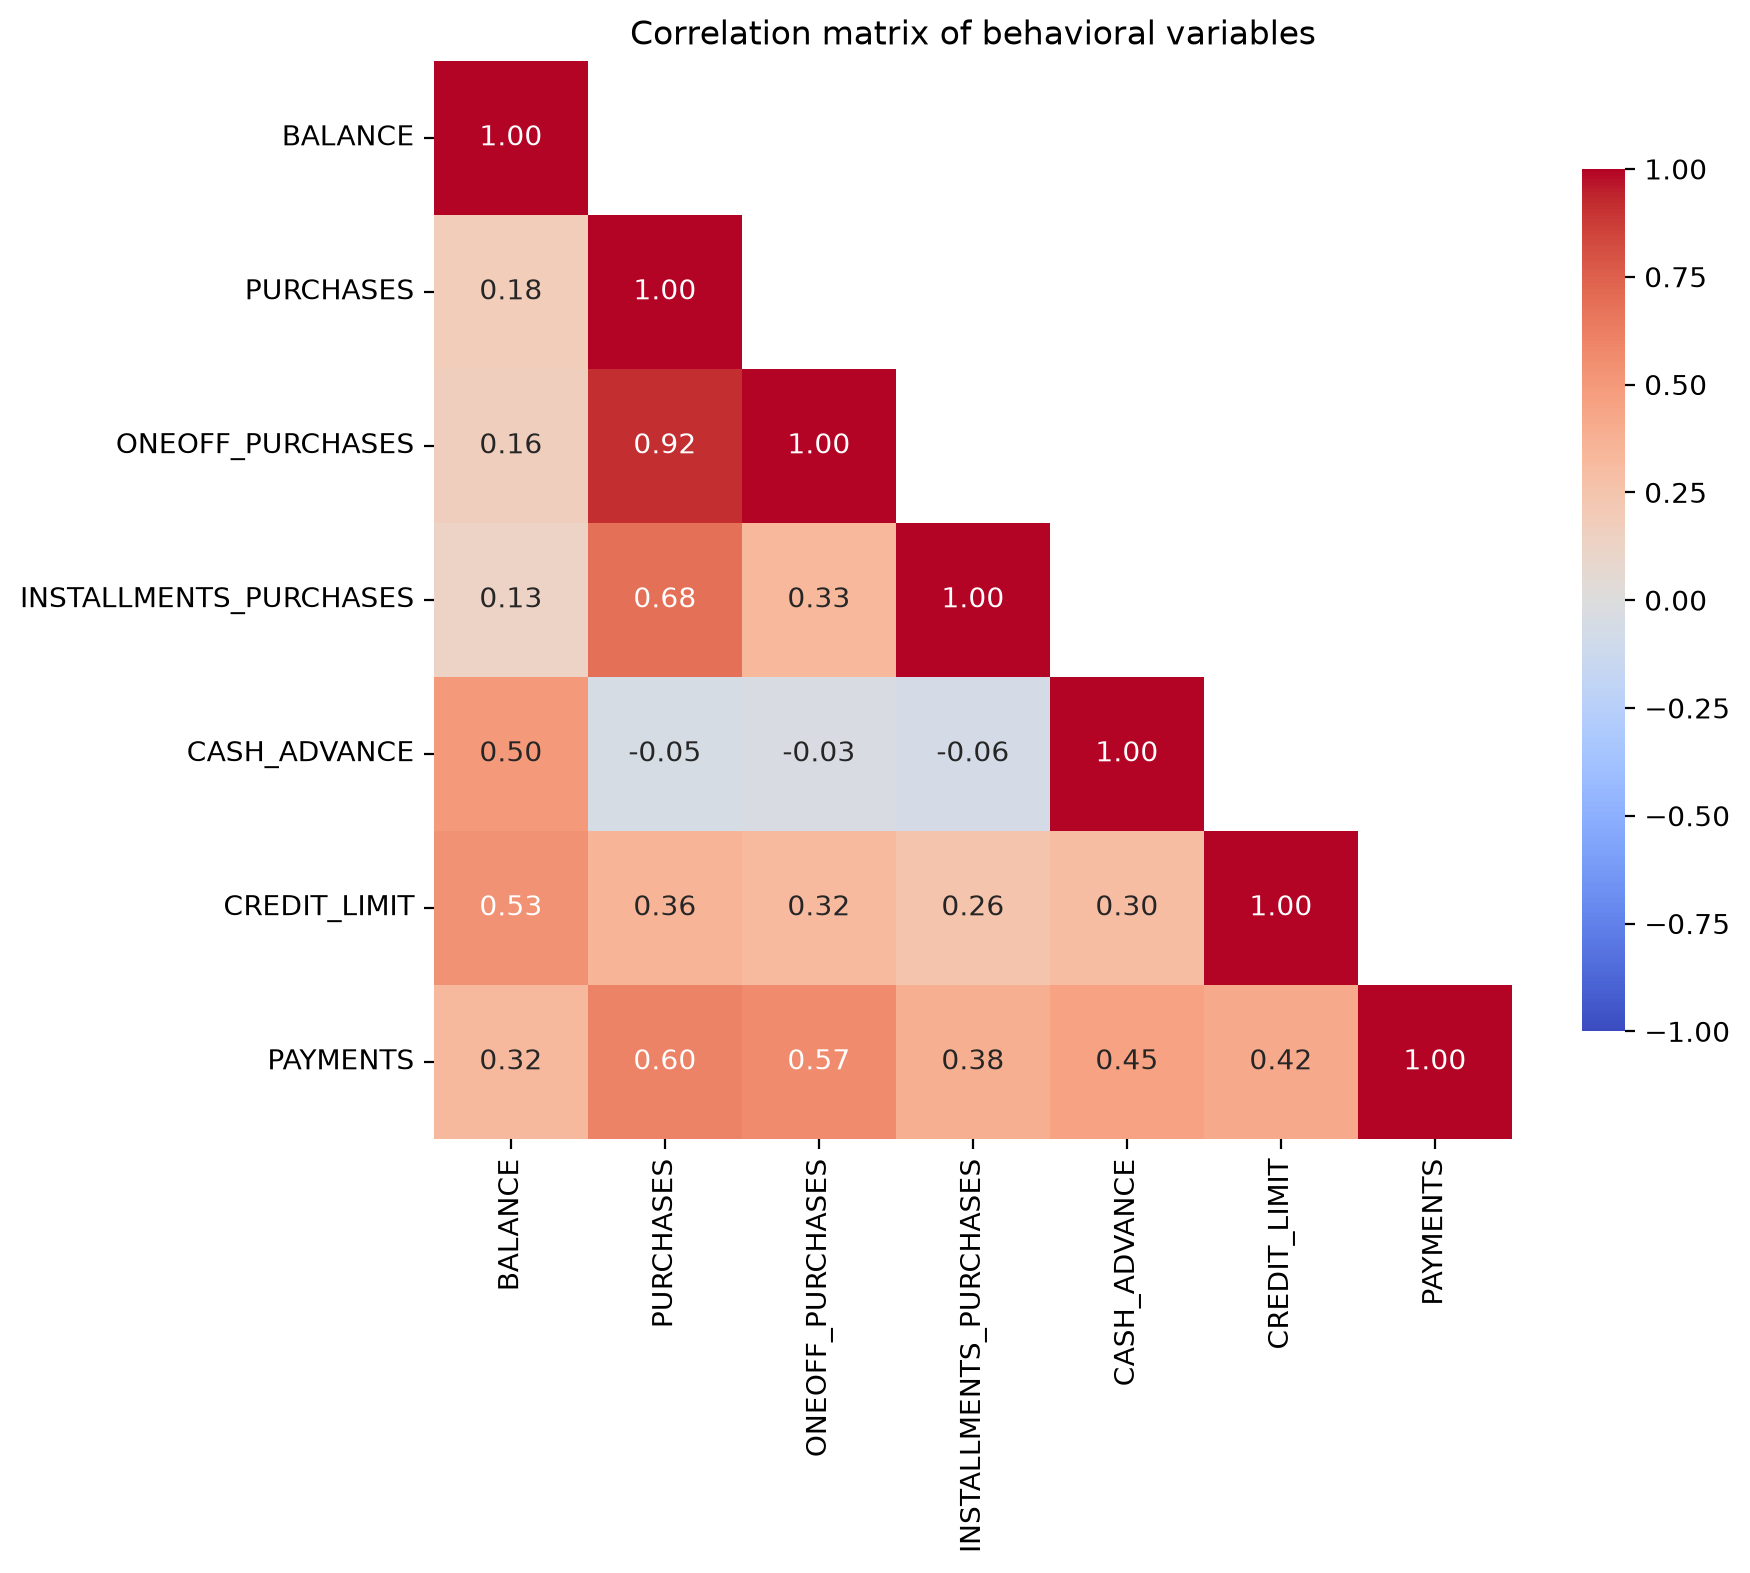

In [35]:
corr = df.drop(columns=["CUST_ID"]).corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, mask=mask, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix of behavioral variables")
plt.show()


# 7. Outliers - Boxplots (IQR)

Boxplots per numerical variable (brief line 41). The IQR bounds are computed explicitly and the number of outliers per column is reported in each title and printed as a table.


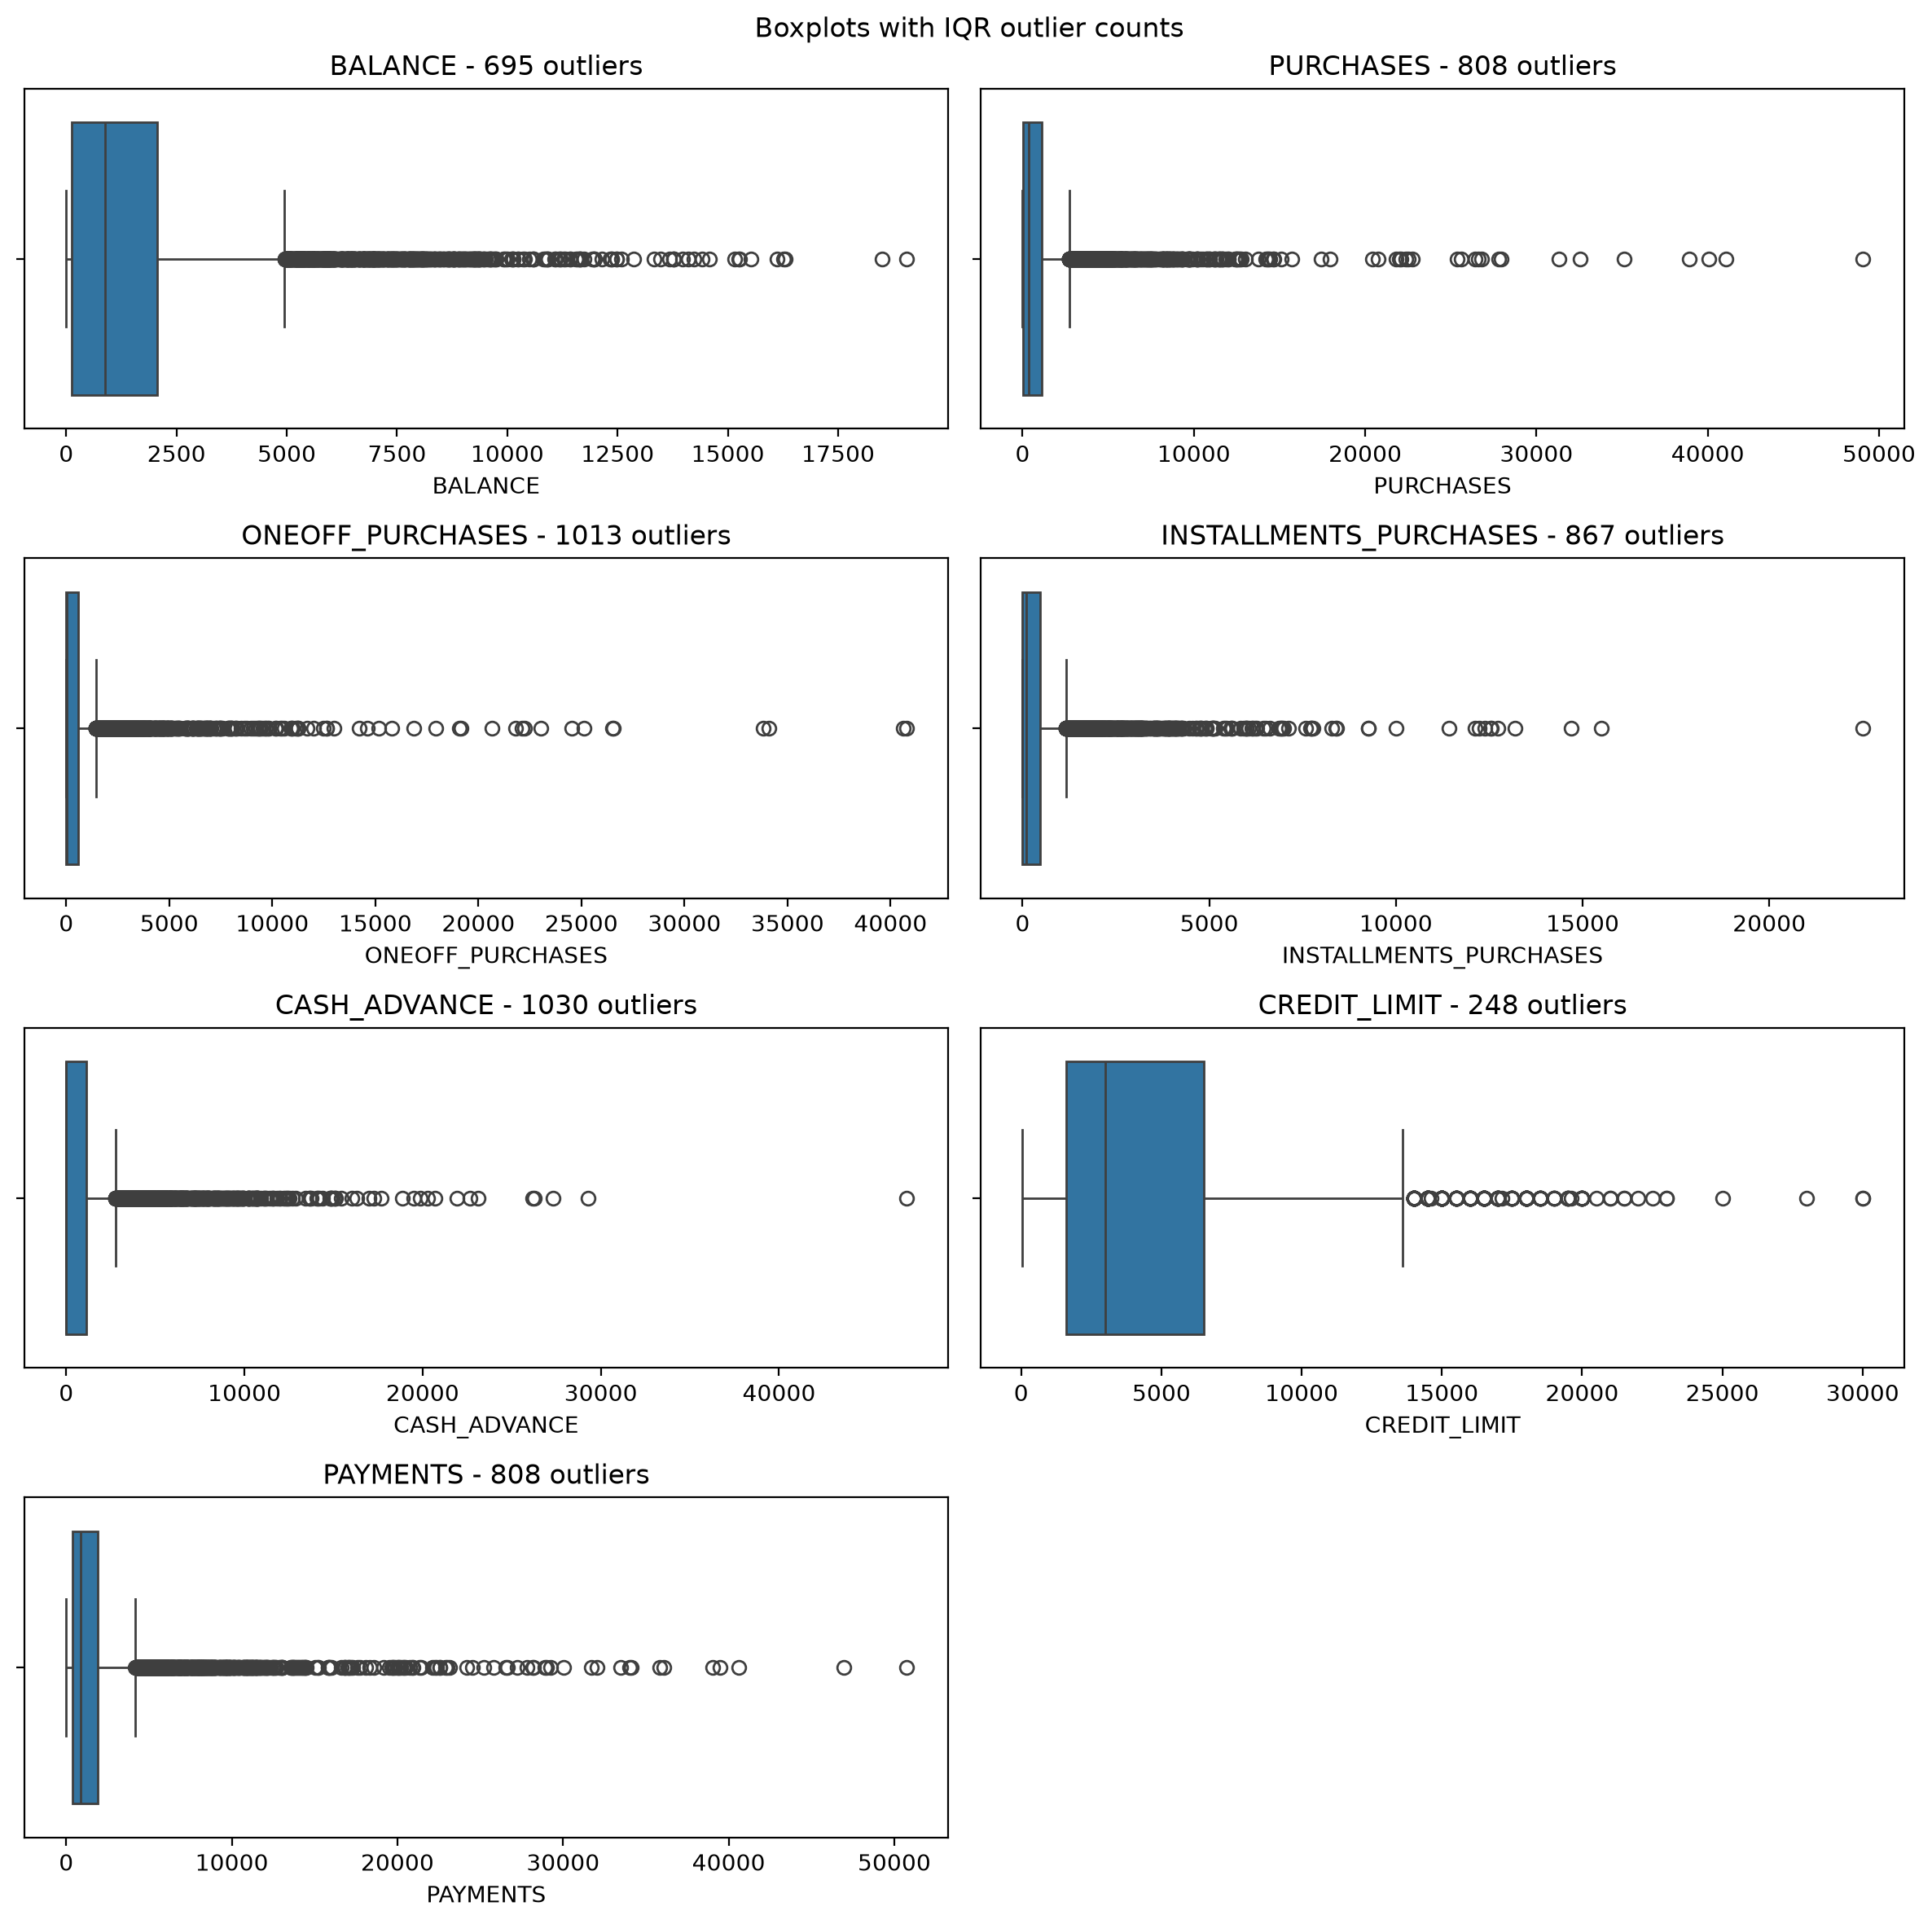

,outlier_count
BALANCE,695
PURCHASES,808
ONEOFF_PURCHASES,1013
INSTALLMENTS_PURCHASES,867
CASH_ADVANCE,1030
CREDIT_LIMIT,248
PAYMENTS,808


In [36]:
import math

n = len(behavioral)
cols = 2
rows = math.ceil(n / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 3 * rows))
axes = axes.ravel()

outlier_counts = {}
for i, (ax, col) in enumerate(zip(axes, behavioral)):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((df[col] < lo) | (df[col] > hi)).sum())
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"{col} - {outlier_counts[col]} outliers")

for ax in axes[n:]:
    ax.remove()

fig.suptitle("Boxplots with IQR outlier counts")
fig.tight_layout()
plt.show()

pd.Series(outlier_counts, name="outlier_count").to_frame()
